In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

In [2]:
mode = 'BandRemoval:4'
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
ds_path = os.path.join(model_dir, f"{model_name}_dataset.npy")
print(path, ds_path)

D:/DeepSSFP/block_phantom_bandremoval_4 D:/DeepSSFP/block_phantom_dataset.npy


Saved dataset found. Loading from file: D:/DeepSSFP/block_phantom_dataset.npy


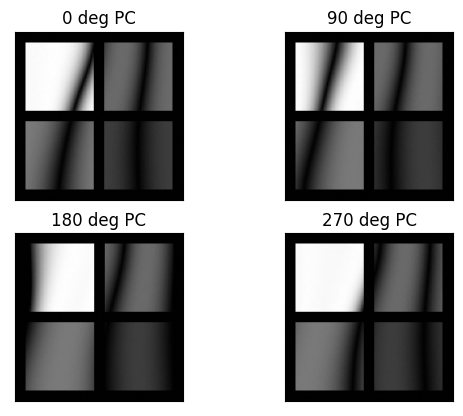

(160, 128, 128, 8) (160, 128, 128, 2)
-0.007850567144167818 0.09967612561713206 -0.009491002499543273 0.07863017274655348
Selected indices: [12 14 21]
Figure size: (10, 6)


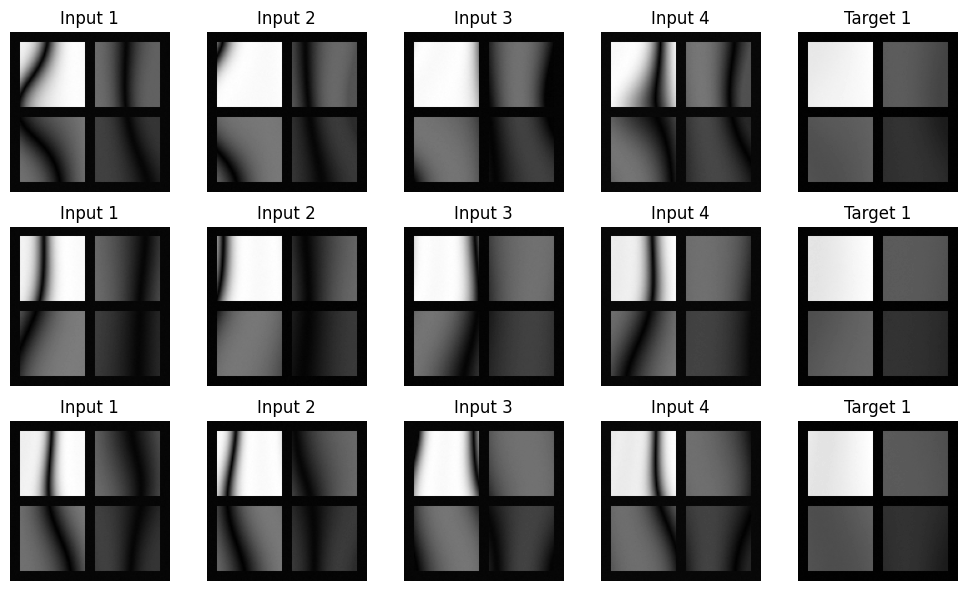

In [3]:
if(os.path.isfile(ds_path)):
    print(f'Saved dataset found. Loading from file: {ds_path}')
    dataset = np.load(ds_path, allow_pickle=True)[0]
else:
    slices = 200
    dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4],
                                          npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                          useRotate=True, useDeform=True)
    np.save(ds_path, [dataset])

data = dataset['M']
data.shape
mssfp.plot_dataset(data, slice=0)
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)
print(ds.inputScaler.mean, ds.inputScaler.std, ds.outputScaler.mean, ds.outputScaler.std)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=3
)

In [ ]:
# Basic training
model, history, ds, predictions = deepssfp.train(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir,
    custom_dataset=ds,
    epochs=400,
    use_early_stopping=False,
    patience=200,
    continue_training=False
)

2025-03-21 20:42:32,955 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_bandremoval_4
2025-03-21 20:42:32,956 - DeepSSFP - INFO - Training DataSet: (160, 128, 128, 8) | (160, 128, 128, 2)
2025-03-21 20:42:32,957 - DeepSSFP - INFO - Test DataSet: (40, 128, 128, 8) | (40, 128, 128, 2)
2025-03-21 20:42:33,532 - DeepSSFP - INFO - Loading existing model from D:/DeepSSFP/block_phantom_bandremoval_4.keras
2025-03-21 20:42:38,995 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_bandremoval_4_history.npz
2025-03-21 20:42:39,000 - DeepSSFP - INFO - Continuing training from epoch 400


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 8) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 2336        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-21 20:42:39,520 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_bandremoval_4.keras


2/2 [==============================] - 4s 390ms/step - loss: 8.5960e-05 - mean_absolute_error: 0.0071


2025-03-21 20:42:43,706 - DeepSSFP - INFO - Training Complete. Loss: 0.0001, MAE: 0.0071
2025-03-21 20:42:43,707 - DeepSSFP - INFO - Time Elapsed: 4.70 seconds


2025-03-21 20:42:43,727 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_bandremoval_4
2025-03-21 20:42:44,251 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_bandremoval_4.keras
2025-03-21 20:42:44,252 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_bandremoval_4_history.npz
2025-03-21 20:42:45,209 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_bandremoval_4_training_history.png


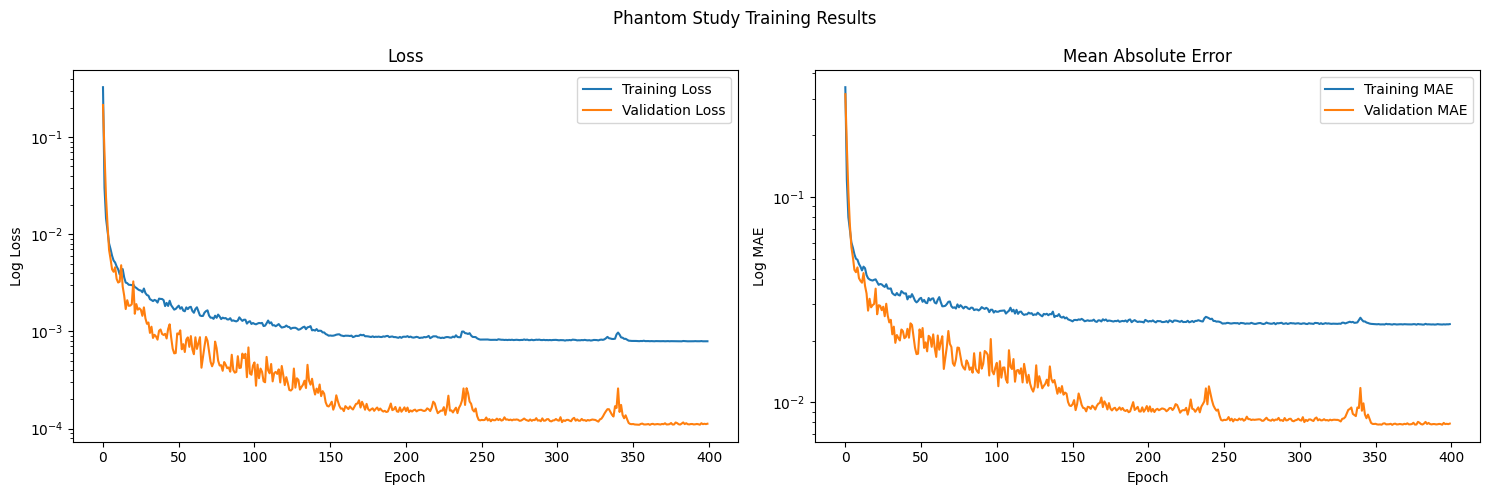

In [5]:
model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir
)

deepssfp.plot_training_history(
    history_dict,
    title="Phantom Study Training Results",
    save_path=f"{path}_training_history.png"
)

2025-03-21 20:42:55,731 - DeepSSFP - INFO - Making predictions on data with shape (40, 128, 128, 8)
2025-03-21 20:42:56,802 - DeepSSFP - INFO - Predictions complete. Output shape: (40, 128, 128, 2)


Selected indices: [6 0]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/block_phantom_bandremoval_4_prediction_results.png


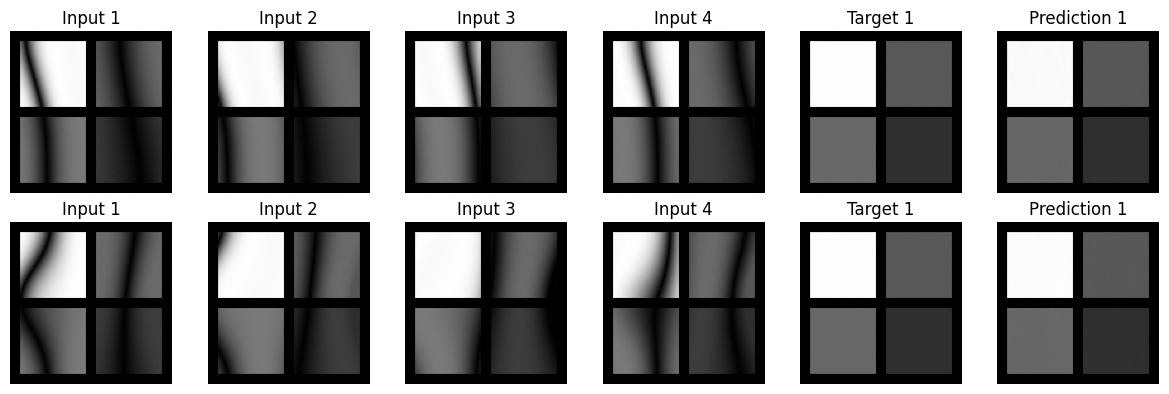

In [6]:
ds = deepssfp.Dataset(mode, input_data=data)
x_test = ds.inputScaler.inverse_transform(ds.x_test)
y_test = ds.outputScaler.inverse_transform(ds.y_test)
predictions = ds.outputScaler.inverse_transform(deepssfp.predict(model, ds.x_test))

deepssfp.visualize_images(
    input_images=x_test,
    target_images=y_test,
    predicted_images=predictions,
    num_samples=2,
    save_path=f"{path}_prediction_results.png"
)

(40, 128, 128) (40, 128, 128)


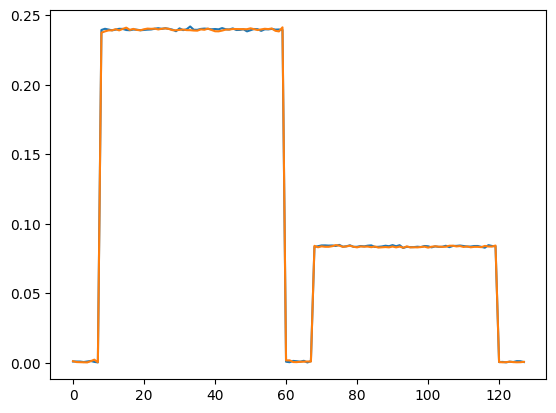

Target shape: (40, 128, 128)
Prediction shape: (40, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4.]
IDs to plot: [1. 2. 3. 4.]
Training history plot saved to D:/DeepSSFP/block_phantom_bandremoval_4_metrics_scatter


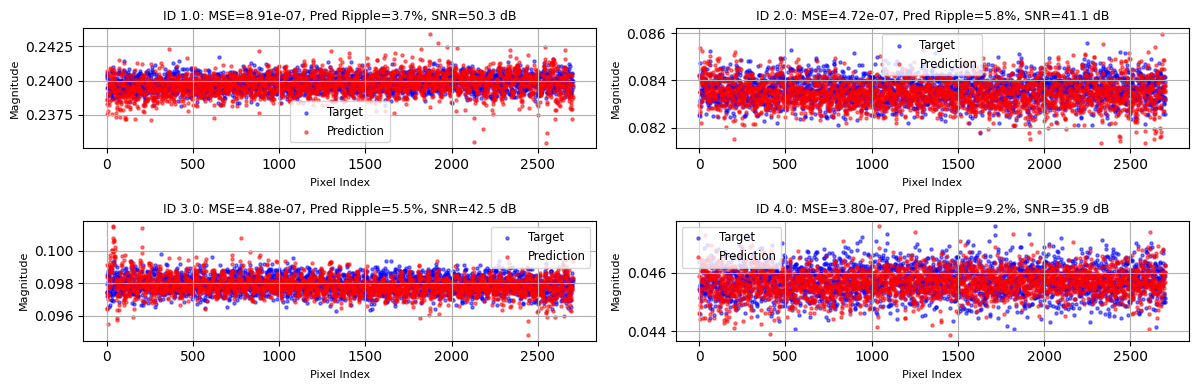

Training history plot saved to D:/DeepSSFP/block_phantom_bandremoval_4_metrics


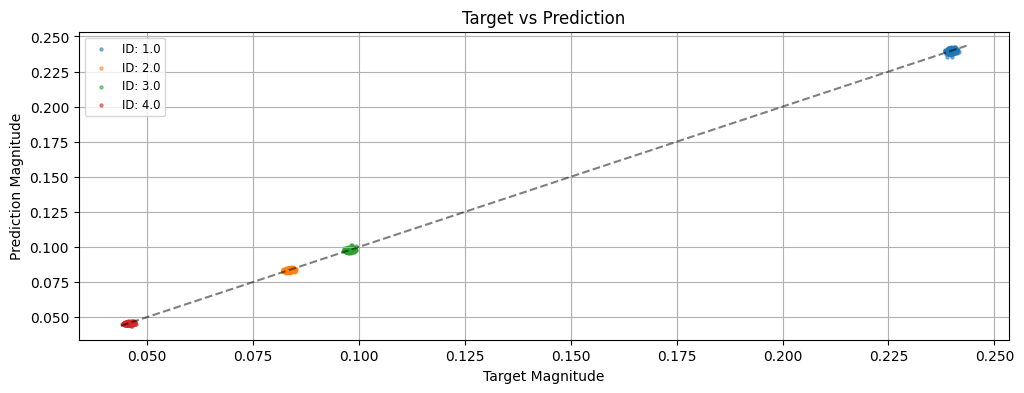


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=8.91e-07, MAE=7.18e-04, Pred Min=0.2351, Pred Max=0.2439, Pred Ripple=3.70%, Pred SNR=50.3 dB, Target Min=0.2375, Target Max=0.2415, Target Ripple=1.66%, Target SNR=50.4 dB, Samples=40, Pixels=2704
ID 2.0: MSE=4.72e-07, MAE=5.40e-04, Pred Min=0.0812, Pred Max=0.0860, Pred Ripple=5.81%, Pred SNR=41.1 dB, Target Min=0.0819, Target Max=0.0854, Target Ripple=4.25%, Target SNR=41.3 dB, Samples=40, Pixels=2704
ID 3.0: MSE=4.88e-07, MAE=5.47e-04, Pred Min=0.0952, Pred Max=0.1006, Pred Ripple=5.54%, Pred SNR=42.5 dB, Target Min=0.0961, Target Max=0.0998, Target Ripple=3.70%, Target SNR=42.7 dB, Samples=40, Pixels=2704
ID 4.0: MSE=3.80e-07, MAE=4.86e-04, Pred Min=0.0436, Pred Max=0.0478, Pred Ripple=9.21%, Pred SNR=35.9 dB, Target Min=0.0439, Target Max=0.0475, Target Ripple=7.87%, Target SNR=36.1 dB, Samples=40, Pixels=2704
{1.0: {'mse': 8.905755890996778e-07, 'mae': 0.0007181360624178521, 'pred_min': 0.23508711, 'pred_max': 0.2

In [7]:
pred = deepssfp.from_pairs_to_complex(predictions)
target = deepssfp.from_pairs_to_complex(y_test)
print(target.shape, pred.shape)

plt.plot(np.abs(target[0,20,:]))
plt.plot(np.abs(pred[0,20,:]))
plt.show()

metrics = deepssfp.evaluate_band_reduction(target, pred, dataset['seg'], sort_values=False, fig_size=(6, 2), save_path=f"{path}_metrics")
print(metrics)